# Data

## Dataset Overview

In [21]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(rstatix)
source("config.R")

In [2]:
cookiecat.data <- read.csv(COOKIECATS_DATA)

str(cookiecat.data)

'data.frame':	90189 obs. of  5 variables:
 $ userid        : int  116 337 377 483 488 540 1066 1444 1574 1587 ...
 $ version       : chr  "gate_30" "gate_30" "gate_40" "gate_40" ...
 $ sum_gamerounds: int  3 38 165 1 179 187 0 2 108 153 ...
 $ retention_1   : logi  FALSE TRUE TRUE FALSE TRUE TRUE ...
 $ retention_7   : logi  FALSE FALSE FALSE FALSE TRUE TRUE ...


In [3]:
summary(cookiecat.data)

     userid          version          sum_gamerounds     retention_1    
 Min.   :    116   Length:90189       Min.   :    0.00   Mode :logical  
 1st Qu.:2512230   Class :character   1st Qu.:    5.00   FALSE:50036    
 Median :4995815   Mode  :character   Median :   16.00   TRUE :40153    
 Mean   :4998412                      Mean   :   51.87                  
 3rd Qu.:7496452                      3rd Qu.:   51.00                  
 Max.   :9999861                      Max.   :49854.00                  
 retention_7    
 Mode :logical  
 FALSE:73408    
 TRUE :16781    
                
                
                

In [4]:
check_missing <- function(df, df.name = "") {
  missing.idx <- which(!complete.cases(df))
  cat(df.name, ": Found", length(missing.idx), "missing rows\n")
  if (length(missing.idx) > 0) print(df[missing.idx, ], row.names = FALSE)
  invisible(missing.idx)
}

check_missing(cookiecat.data, "cookiecat.data")

cookiecat.data : Found 0 missing rows


# Exploratory Data Analysis

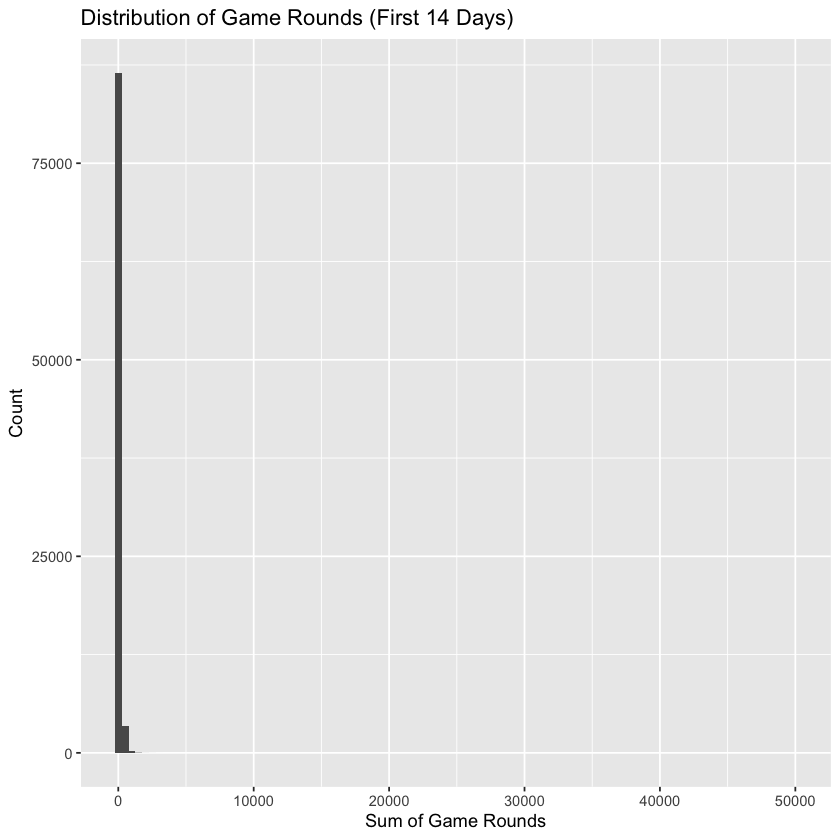

In [5]:
ggplot(cookiecat.data, aes(x = sum_gamerounds)) +
  geom_histogram(bins = 100) +
  labs(title = "Distribution of Game Rounds (First 14 Days)",
       x = "Sum of Game Rounds",
       y = "Count")

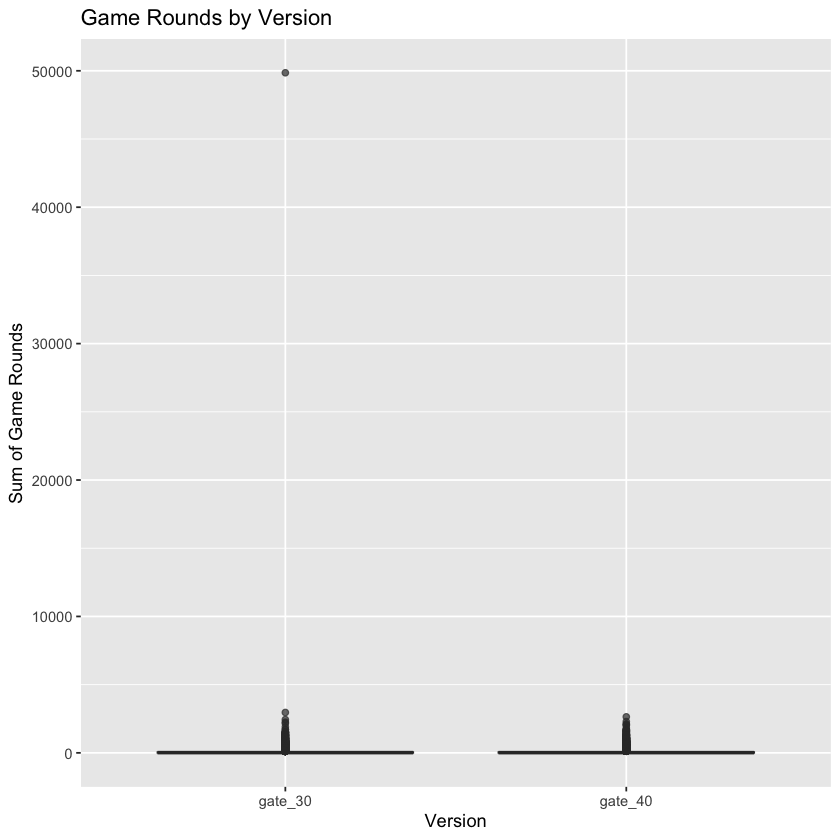

In [6]:
ggplot(cookiecat.data, aes(x = version, y = sum_gamerounds)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Game Rounds by Version",
       x = "Version",
       y = "Sum of Game Rounds") +
  theme(legend.position = "none")


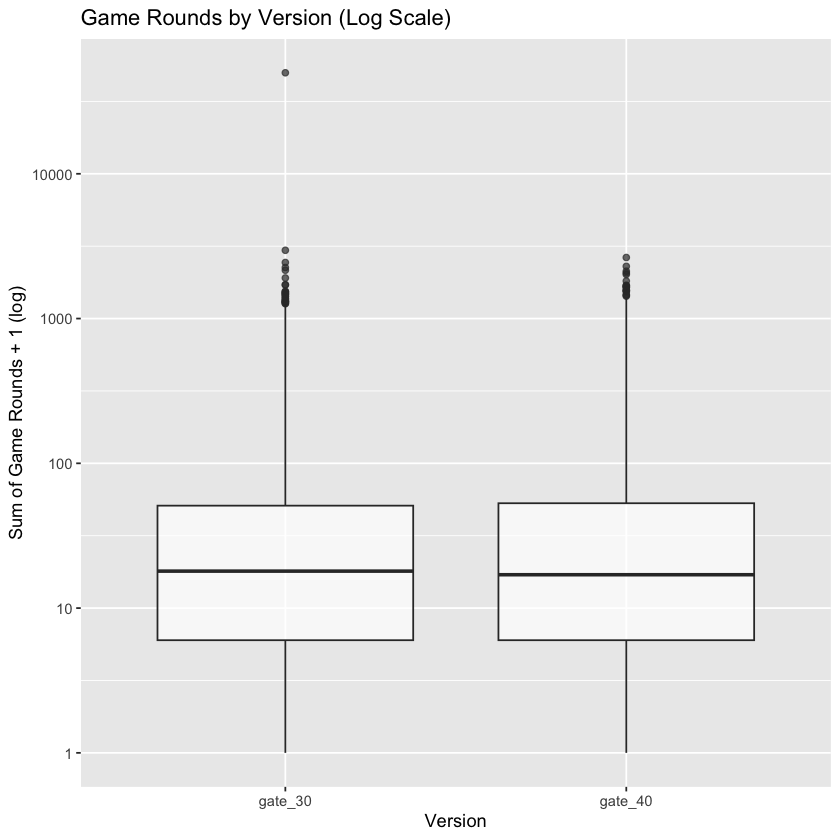

In [7]:
ggplot(cookiecat.data, aes(x = version, y = sum_gamerounds + 1)) +
  geom_boxplot(alpha = 0.7) +
  scale_y_log10() +
  labs(title = "Game Rounds by Version (Log Scale)",
       x = "Version",
       y = "Sum of Game Rounds + 1 (log)")


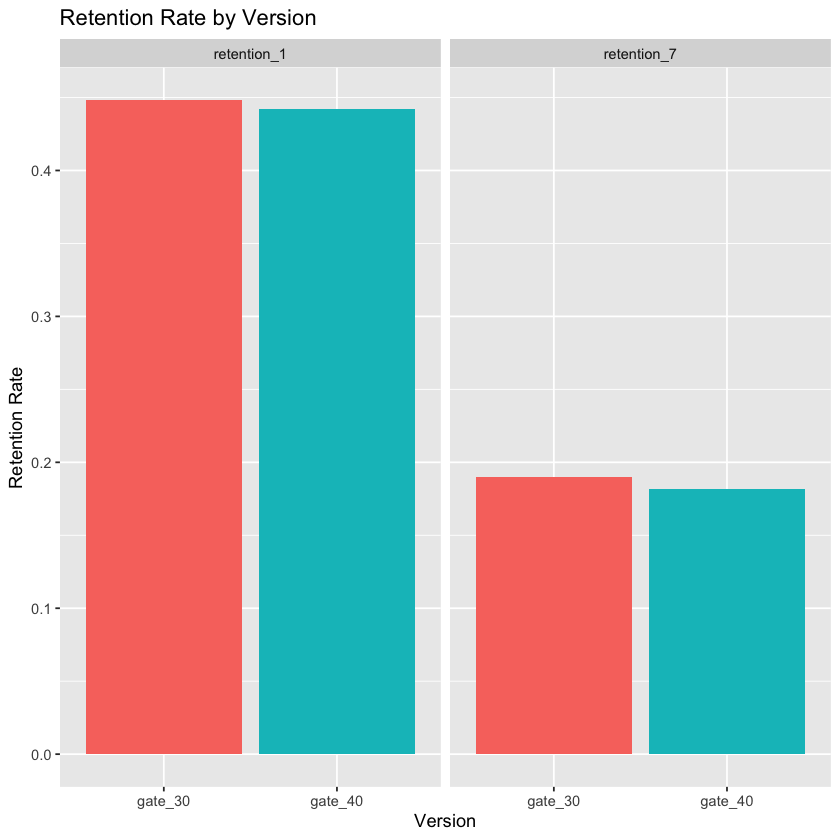

In [8]:
cookiecat.data %>%
  pivot_longer(cols = c(retention_1, retention_7),
               names_to = "retention_type",
               values_to = "retained") %>%
  group_by(version, retention_type) %>%
  summarise(retention_rate = mean(retained), .groups = "drop") %>%
  ggplot(aes(x = version, y = retention_rate, fill = version)) +
  geom_bar(stat = "identity") +
  facet_wrap(~retention_type) +
  labs(title = "Retention Rate by Version",
       x = "Version", y = "Retention Rate") +
  theme(legend.position = "none")


# Frequentist

## Retention Rate: Chi-Square Test


In [9]:
retention_1_table <- table(cookiecat.data$version, cookiecat.data$retention_1)
result_retention_1 <- chisq.test(retention_1_table)
effect_retention_1 <- cramer_v(retention_1_table)

retention_1_results <- data.frame(
  metric     = "retention_1",
  chi_square = round(result_retention_1$statistic, 3),
  df         = result_retention_1$parameter,
  p_value    = round(result_retention_1$p.value, 4),
  cramers_v  = round(effect_retention_1, 4)
)

print(retention_1_results, row.names = FALSE)


      metric chi_square df p_value cramers_v
 retention_1      3.159  1  0.0755    0.0059


In [10]:
retention_7_table <- table(cookiecat.data$version, cookiecat.data$retention_7)
result_retention_7 <- chisq.test(retention_7_table)
effect_retention_7 <- cramer_v(retention_7_table)

retention_7_results <- data.frame(
  metric     = "retention_7",
  chi_square = round(result_retention_7$statistic, 3),
  df         = result_retention_7$parameter,
  p_value    = round(result_retention_7$p.value, 4),
  cramers_v  = round(effect_retention_7, 4)
)

print(retention_7_results, row.names = FALSE)


      metric chi_square df p_value cramers_v
 retention_7      9.959  1  0.0016    0.0105


In [11]:
chisq_results <- data.frame(
  metric     = c("retention_1", "retention_7"),
  chi_square = round(c(result_retention_1$statistic, result_retention_7$statistic), 3),
  df         = c(result_retention_1$parameter, result_retention_7$parameter),
  p_value    = round(c(result_retention_1$p.value, result_retention_7$p.value), 4),
  cramers_v  = round(c(effect_retention_1, effect_retention_7), 4)
)

print(chisq_results, row.names = FALSE)

      metric chi_square df p_value cramers_v
 retention_1      3.159  1  0.0755    0.0059
 retention_7      9.959  1  0.0016    0.0105


##  Game Rounds: Mann-Whitney U Test

In [12]:
result_sum_gamerounds <- wilcox.test(sum_gamerounds ~ version, data = cookiecat.data)

mw_results <- data.frame(
  metric    = "sum_gamerounds",
  W         = result_sum_gamerounds$statistic,
  p_value   = round(result_sum_gamerounds$p.value, 4)
)

print(mw_results, row.names = FALSE)

         metric          W p_value
 sum_gamerounds 1024331250  0.0502


# Bayesian

## Retention_7: Posterior Analysis

In [13]:
gate30_success <- retention_7_table["gate_30", "TRUE"]
gate30_total   <- sum(retention_7_table["gate_30", ])

gate40_success <- retention_7_table["gate_40", "TRUE"]
gate40_total   <- sum(retention_7_table["gate_40", ])

alpha_30 <- 1 + gate30_success
beta_30   <- 1 + gate30_total - gate30_success

alpha_40 <- 1 + gate40_success
beta_40   <- 1 + gate40_total - gate40_success

In [14]:
set.seed(42)
n_samples <- 100000
samples_30 <- rbeta(n_samples, alpha_30, beta_30)
samples_40 <- rbeta(n_samples, alpha_40, beta_40)

p_gate30_better <- mean(samples_30 > samples_40)
cat("P(gate_30 > gate_40):", round(p_gate30_better, 4), "\n")


P(gate_30 > gate_40): 0.9992 


In [15]:
diff_samples <- samples_30 - samples_40
ci_lower <- quantile(diff_samples, 0.025)
ci_upper <- quantile(diff_samples, 0.975)

cat("95% Credible Interval:", round(ci_lower, 4), "~", round(ci_upper, 4), "\n")

95% Credible Interval: 0.0031 ~ 0.0133 


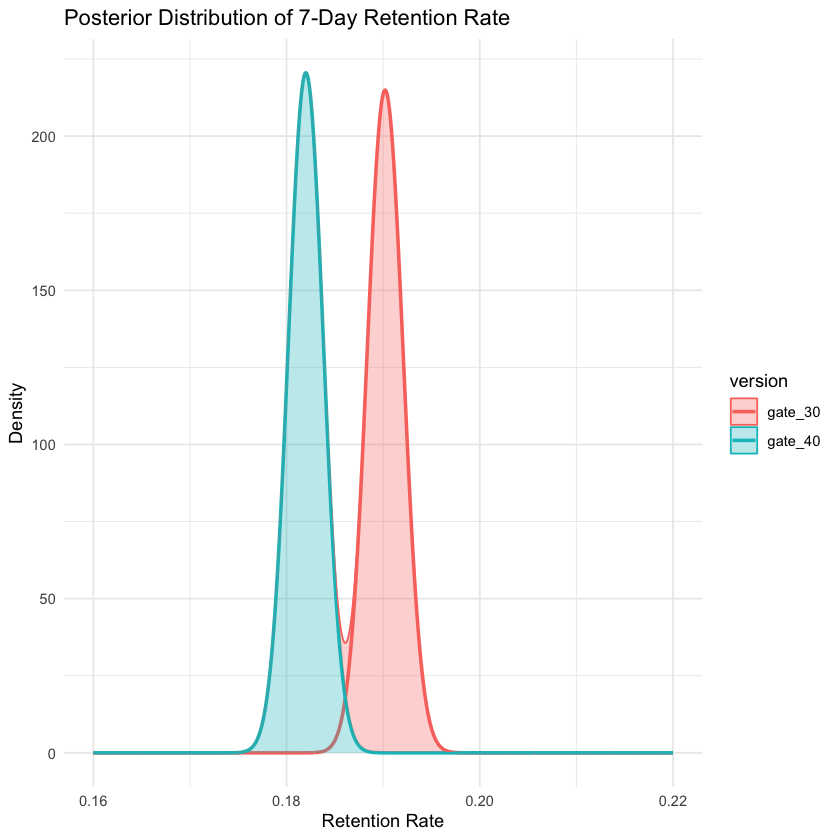

In [16]:
x <- seq(0.16, 0.22, length.out = 1000)

df_plot <- data.frame(
  x       = rep(x, 2),
  density = c(dbeta(x, alpha_30, beta_30),
              dbeta(x, alpha_40, beta_40)),
  version = rep(c("gate_30", "gate_40"), each = 1000)
)

ggplot(df_plot, aes(x = x, y = density, fill = version, color = version)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of 7-Day Retention Rate",
       x = "Retention Rate",
       y = "Density") +
  theme_minimal()


## Retention_1: Posterior Analysis

In [17]:
gate30_success_r1 <- retention_1_table["gate_30", "TRUE"]
gate30_total_r1   <- sum(retention_1_table["gate_30", ])

gate40_success_r1 <- retention_1_table["gate_40", "TRUE"]
gate40_total_r1   <- sum(retention_1_table["gate_40", ])

alpha_30_r1 <- 1 + gate30_success_r1
beta_30_r1  <- 1 + gate30_total_r1 - gate30_success_r1

alpha_40_r1 <- 1 + gate40_success_r1
beta_40_r1  <- 1 + gate40_total_r1 - gate40_success_r1

In [18]:
set.seed(42)
samples_30_r1 <- rbeta(n_samples, alpha_30_r1, beta_30_r1)
samples_40_r1 <- rbeta(n_samples, alpha_40_r1, beta_40_r1)

p_gate30_better_r1 <- mean(samples_30_r1 > samples_40_r1)
cat("P(gate_30 > gate_40) retention_1:", round(p_gate30_better_r1, 4), "\n")

P(gate_30 > gate_40) retention_1: 0.9619 


In [19]:
diff_samples_r1 <- samples_30_r1 - samples_40_r1
ci_lower_r1 <- quantile(diff_samples_r1, 0.025)
ci_upper_r1 <- quantile(diff_samples_r1, 0.975)
cat("95% Credible Interval:", round(ci_lower_r1, 4), "~", round(ci_upper_r1, 4), "\n")

95% Credible Interval: -6e-04 ~ 0.0124 


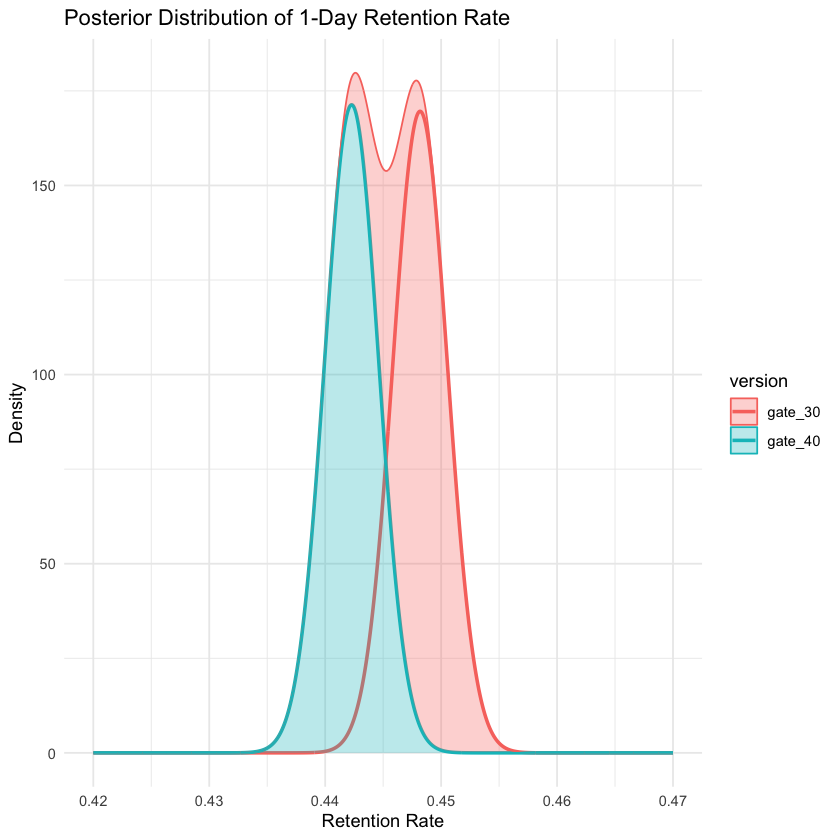

In [20]:
x_r1 <- seq(0.42, 0.47, length.out = 1000)

df_plot_r1 <- data.frame(
  x       = rep(x_r1, 2),
  density = c(dbeta(x_r1, alpha_30_r1, beta_30_r1),
              dbeta(x_r1, alpha_40_r1, beta_40_r1)),
  version = rep(c("gate_30", "gate_40"), each = 1000)
)

ggplot(df_plot_r1, aes(x = x, y = density, fill = version, color = version)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of 1-Day Retention Rate",
       x = "Retention Rate",
       y = "Density") +
  theme_minimal()
